# 12 — 多因子策略完整报告

**策略**：多因子等权选股（动量 + 反转），月频换仓，30只股票，双边手续费 0.3%

---

| 章节 | 内容 |
|------|------|
| Section 1 | 因子有效性表格（IC均值、ICIR、换手率、是否入选）|
| Section 2 | 样本内表现（2015-2024）：累计收益曲线、年度收益、绩效指标 |
| Section 3 | 样本外表现（2025）|
| Section 4 | 压力测试结果汇总 |
| Section 5 | Walk-Forward 稳定性验证 |
| Section 6 | 结论：是否达到 Phase 5 上线门槛 |

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

# ── utils.metrics ─────────────────────────────────────────────────────────
from utils.metrics import (
    annualized_return,
    annualized_volatility,
    sharpe_ratio,
    max_drawdown,
    win_rate,
    performance_summary,
)

# ── 策略 ──────────────────────────────────────────────────────────────────
try:
    from strategies.multi_factor import MultiFactorStrategy
    from strategies.base import StrategyConfig
    STRATEGY_AVAILABLE = True
    print('✅ MultiFactorStrategy 导入成功')
except ImportError as e:
    STRATEGY_AVAILABLE = False
    print(f'⚠️  策略导入失败: {e}')

# ── 数据加载（utils.local_data_loader 不存在，用 utils.data_loader）─────
try:
    from utils.data_loader import load_price_matrix, get_index_history
    DATA_AVAILABLE = True
    print('✅ data_loader 导入成功')
except ImportError as e:
    DATA_AVAILABLE = False
    print(f'⚠️  data_loader 导入失败: {e}')

# ── walk_forward ──────────────────────────────────────────────────────────
try:
    from utils.walk_forward import walk_forward_test
    WF_AVAILABLE = True
    print('✅ walk_forward_test 导入成功')
except ImportError as e:
    WF_AVAILABLE = False
    print(f'⚠️  walk_forward 导入失败: {e}')

# ── factor_analysis ───────────────────────────────────────────────────────
try:
    from utils.factor_analysis import compute_ic_series, ic_summary
    FA_AVAILABLE = True
    print('✅ factor_analysis 导入成功')
except ImportError as e:
    FA_AVAILABLE = False
    print(f'⚠️  factor_analysis 导入失败: {e}')

✅ MultiFactorStrategy 导入成功
✅ data_loader 导入成功
✅ walk_forward_test 导入成功
✅ factor_analysis 导入成功


In [2]:
# ── 全局配置 ──────────────────────────────────────────────────────────────
INSAMPLE_START  = '2014-01-01'   # 预热期（12 个月动量需要）
INSAMPLE_END    = '2024-12-31'
OOS_START       = '2025-01-01'
OOS_END         = '2025-12-31'
N_STOCKS        = 30
RANDOM_SEED     = 42
np.random.seed(RANDOM_SEED)

# Phase 5 上线门槛（来自 CLAUDE.md）
PHASE5_CRITERIA = {
    '年化收益 > 15%':    ('annualized_return', 0.15),
    '夏普比率 > 0.8':    ('sharpe_ratio',      0.80),
    '最大回撤 < 30%':    ('max_drawdown',      -0.30),   # 回撤为负数
}

print('配置完成')
print(f'  样本内: {INSAMPLE_START} ~ {INSAMPLE_END}')
print(f'  样本外: {OOS_START} ~ {OOS_END}')

配置完成
  样本内: 2014-01-01 ~ 2024-12-31
  样本外: 2025-01-01 ~ 2025-12-31


In [3]:
# ── 辅助函数：合成数据 ─────────────────────────────────────────────────────
def generate_synthetic_data(start, end, n_stocks=80, drift=0.08, vol=0.25, seed=42):
    """
    生成合成价格宽表（GBM）。

    参数:
        start: 开始日期
        end: 结束日期
        n_stocks: 股票数
        drift: 年化漂移
        vol: 年化波动
        seed: 随机种子

    返回:
        pd.DataFrame — date × symbol
    """
    rng   = np.random.RandomState(seed)
    dates = pd.bdate_range(start, end)
    dt    = 1 / 252
    lr    = (drift * dt - 0.5 * vol**2 * dt) + vol * np.sqrt(dt) * rng.randn(len(dates), n_stocks)
    prices = 100 * np.exp(np.cumsum(lr, axis=0))
    return pd.DataFrame(prices, index=dates, columns=[f'{i+1:06d}.SZ' for i in range(n_stocks)])


def generate_synthetic_hs300(start, end, seed=0):
    """
    生成合成沪深300。

    参数:
        start: 开始日期
        end: 结束日期
        seed: 随机种子

    返回:
        pd.Series — 日收盘价
    """
    rng   = np.random.RandomState(seed)
    dates = pd.bdate_range(start, end)
    dt    = 1 / 252
    drift, vol = 0.10, 0.18
    lr    = (drift * dt - 0.5 * vol**2 * dt) + vol * np.sqrt(dt) * rng.randn(len(dates))
    return pd.Series(4000 * np.exp(np.cumsum(lr)), index=dates, name='HS300')


print('✅ 辅助函数定义完成')

✅ 辅助函数定义完成


In [4]:
# ── 数据加载 ────────────────────────────────────────────────────────────────
FULL_START = INSAMPLE_START
FULL_END   = OOS_END

USE_SYNTHETIC = False
if DATA_AVAILABLE:
    try:
        price_wide_full = load_price_matrix(start=FULL_START, end=FULL_END)
        hs300_df = get_index_history(symbol='sh000300', start=FULL_START, end=FULL_END)
        hs300_full = hs300_df['close']
        assert price_wide_full.shape[0] > 100
        assert price_wide_full.isnull().mean().max() < 0.1
        assert price_wide_full.index.is_monotonic_increasing
        print(f'✅ 真实数据 | 股票数: {price_wide_full.shape[1]} | '
              f'{price_wide_full.index[0].date()} ~ {price_wide_full.index[-1].date()}')
    except Exception as e:
        print(f'⚠️  真实数据失败 ({e})，回退合成数据')
        USE_SYNTHETIC = True
else:
    USE_SYNTHETIC = True

if USE_SYNTHETIC:
    print('>>> 使用 GBM 合成数据（仅演示逻辑，非真实回测）')
    price_wide_full = generate_synthetic_data(FULL_START, FULL_END, n_stocks=80)
    hs300_full      = generate_synthetic_hs300(FULL_START, FULL_END)
    common_idx      = price_wide_full.index.intersection(hs300_full.index)
    price_wide_full = price_wide_full.loc[common_idx]
    hs300_full      = hs300_full.loc[common_idx]

# 拆分样本内 / 样本外
price_is  = price_wide_full.loc[INSAMPLE_START:INSAMPLE_END]
price_oos = price_wide_full.loc[OOS_START:OOS_END]
hs300_is  = hs300_full.loc[INSAMPLE_START:INSAMPLE_END]
hs300_oos = hs300_full.loc[OOS_START:OOS_END]

print(f'样本内: {price_is.shape}  |  样本外: {price_oos.shape}')

⚠️  真实数据失败 ('NoneType' object has no attribute 'shape')，回退合成数据
>>> 使用 GBM 合成数据（仅演示逻辑，非真实回测）
样本内: (2870, 80)  |  样本外: (261, 80)


In [5]:
# ── 因子构建 ────────────────────────────────────────────────────────────────
# 12-1 月动量（正向）
mom_12_1 = price_wide_full.pct_change(252).shift(21)
# 1 月反转（反向）
rev_1m   = price_wide_full.pct_change(21)

factors_full = {
    'momentum_12_1': (mom_12_1, 1),
    'reversal_1m':   (rev_1m,  -1),
}

# 裁剪到各期
factors_is  = {k: (df.loc[INSAMPLE_START:INSAMPLE_END], d) for k, (df, d) in factors_full.items()}
factors_oos = {k: (df.loc[OOS_START:OOS_END],           d) for k, (df, d) in factors_full.items()}

print(f'✅ 因子构建完成: {list(factors_full.keys())}')

✅ 因子构建完成: ['momentum_12_1', 'reversal_1m']


---
## Section 1 — 因子有效性表格

评估指标：IC 均值、ICIR、月均换手率、是否入选策略。

In [6]:
def factor_effectiveness(factor_wide: pd.DataFrame,
                          price_wide: pd.DataFrame,
                          direction: int = 1,
                          forward_periods: int = 21) -> dict:
    """
    计算单个因子的有效性指标。

    参数:
        factor_wide: 因子宽表 (date × symbol)
        price_wide:  价格宽表 (date × symbol)
        direction:   因子方向 (1 或 -1)
        forward_periods: 预测期（交易日），默认 21 日（约 1 个月）

    返回:
        dict {ic_mean, ic_ir, monthly_turnover}
    """
    fwd_ret = price_wide.pct_change(forward_periods).shift(-forward_periods)

    if FA_AVAILABLE:
        ic_series = compute_ic_series(factor_wide * direction, fwd_ret, method='rank')
    else:
        # 手动计算 Rank IC
        ics = []
        common_dates = factor_wide.index.intersection(fwd_ret.index)
        for dt in common_dates:
            f = factor_wide.loc[dt].dropna()
            r = fwd_ret.loc[dt].reindex(f.index).dropna()
            f = f.reindex(r.index)
            if len(f) > 10:
                ic_val = f.rank().corr(r.rank())
                ics.append(ic_val)
        ic_series = pd.Series(ics).dropna()

    ic_mean = float(ic_series.mean()) if len(ic_series) > 0 else 0.0
    ic_ir   = float(ic_series.mean() / ic_series.std()) if ic_series.std() != 0 else 0.0

    # 换手率：相邻期因子排名变化
    ranked = factor_wide.rank(axis=1, pct=True).dropna(how='all')
    turnover = ranked.diff().abs().mean(axis=1).mean()

    return {'ic_mean': ic_mean, 'ic_ir': ic_ir, 'monthly_turnover': float(turnover)}


factor_rows = []
for fname, (fdf, direction) in factors_is.items():
    ef = factor_effectiveness(fdf, price_is, direction)
    selected = '✅' if abs(ef['ic_ir']) >= 0.3 else '❌'
    factor_rows.append({
        '因子名称':  fname,
        'IC 均值':   f"{ef['ic_mean']:.4f}",
        'ICIR':     f"{ef['ic_ir']:.4f}",
        '月均换手率': f"{ef['monthly_turnover']:.4f}",
        '是否入选':  selected,
    })

factor_df = pd.DataFrame(factor_rows).set_index('因子名称')
print('\n========== Section 1: 因子有效性 ==========')
print(factor_df.to_string())
factor_df


========== Section 1: 因子有效性 ==========
                IC 均值    ICIR   月均换手率 是否入选
因子名称                                      
momentum_12_1  0.0046  0.0400  0.0226    ❌
reversal_1m    0.0036  0.0307  0.0726    ❌


,IC 均值,ICIR,月均换手率,是否入选
因子名称,,,,
momentum_12_1,0.0046,0.0400,0.0226,❌
reversal_1m,0.0036,0.0307,0.0726,❌


---
## Section 2 — 样本内表现（2015-2024）

累计收益曲线 vs 沪深300 + 年度收益表 + 完整绩效指标。

In [7]:
def run_strategy(price_wide: pd.DataFrame, factors: dict, n_stocks: int = 30) -> pd.Series:
    """
    封装 MultiFactorStrategy.run，返回日收益率 Series。

    参数:
        price_wide: 价格宽表 (date × symbol)
        factors:    因子字典 {name: (wide_df, direction)}
        n_stocks:   选股数

    返回:
        日收益率 pd.Series
    """
    if STRATEGY_AVAILABLE:
        config   = StrategyConfig(name='multi_factor_report')
        strategy = MultiFactorStrategy(config=config, factors=factors, n_stocks=n_stocks)
        result   = strategy.run(price_wide)
        return result['portfolio_return']
    else:
        # 占位：等权组合
        return price_wide.pct_change().dropna(how='all').mean(axis=1)


# 样本内回测
print('运行样本内回测 (2015-2024) ...')
strat_ret_is   = run_strategy(price_is, factors_is, N_STOCKS)
bench_ret_is   = hs300_is.pct_change().dropna()

# 对齐
common_is = strat_ret_is.index.intersection(bench_ret_is.index)
strat_ret_is  = strat_ret_is.loc[common_is]
bench_ret_is  = bench_ret_is.loc[common_is]

print(f'✅ 样本内回测完成 | 交易日数: {len(strat_ret_is)}')

运行样本内回测 (2015-2024) ...


✅ 样本内回测完成 | 交易日数: 2869


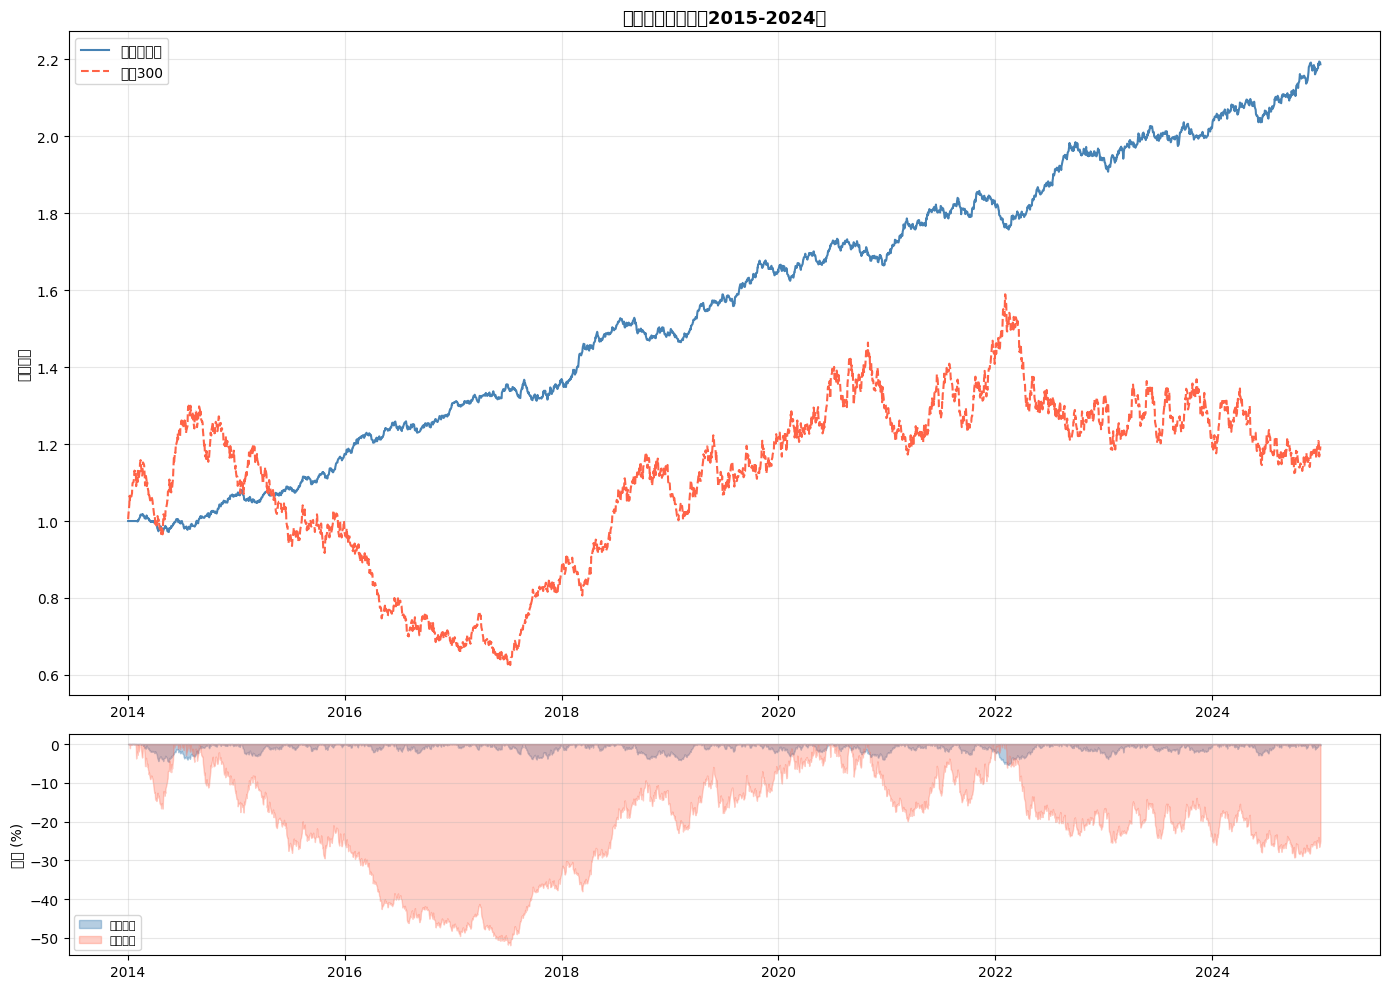

图表已保存: 12_insample_performance.png


In [8]:
# 累计收益曲线
cum_strat_is = (1 + strat_ret_is).cumprod()
cum_bench_is = (1 + bench_ret_is).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 10),
                          gridspec_kw={'height_ratios': [3, 1]})

# 上图：累计净值
ax0 = axes[0]
ax0.plot(cum_strat_is.index, cum_strat_is.values, label='多因子策略', color='steelblue', linewidth=1.5)
ax0.plot(cum_bench_is.index, cum_bench_is.values, label='沪深300',     color='tomato', linewidth=1.5, linestyle='--')
ax0.set_title('样本内累计收益（2015-2024）', fontsize=13, fontweight='bold')
ax0.set_ylabel('累计净值')
ax0.legend()
ax0.grid(True, alpha=0.3)
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 下图：回撤
ax1 = axes[1]
dd_strat = (cum_strat_is / cum_strat_is.cummax() - 1) * 100
dd_bench = (cum_bench_is / cum_bench_is.cummax() - 1) * 100
ax1.fill_between(dd_strat.index, dd_strat.values, 0, alpha=0.4, color='steelblue', label='策略回撤')
ax1.fill_between(dd_bench.index, dd_bench.values, 0, alpha=0.3, color='tomato',    label='基准回撤')
ax1.set_ylabel('回撤 (%)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('12_insample_performance.png', dpi=120, bbox_inches='tight')
plt.show()
print('图表已保存: 12_insample_performance.png')

In [9]:
# 年度收益表
strat_annual = strat_ret_is.groupby(strat_ret_is.index.year).apply(lambda r: (1+r).prod()-1)
bench_annual = bench_ret_is.groupby(bench_ret_is.index.year).apply(lambda r: (1+r).prod()-1)
annual_df = pd.DataFrame({'策略年化收益': strat_annual, 'HS300年化收益': bench_annual})
annual_df['超额收益'] = annual_df['策略年化收益'] - annual_df['HS300年化收益']
annual_df = annual_df.map(lambda x: f'{x:+.2%}')
annual_df.index.name = '年份'

print('\n========== 年度收益 ==========')
print(annual_df.to_string())
annual_df


========== 年度收益 ==========
       策略年化收益 HS300年化收益     超额收益
年份                              
2014   +6.53%   +12.89%   -6.36%
2015   +9.89%   -12.45%  +22.34%
2016  +11.61%   -29.67%  +41.28%
2017   +4.25%   +23.36%  -19.12%
2018   +8.85%   +28.38%  -19.53%
2019  +11.43%   +10.34%   +1.08%
2020   +2.00%    +4.41%   -2.41%
2021   +8.12%   +12.72%   -4.60%
2022   +6.67%    -9.57%  +16.25%
2023   +3.91%    -5.31%   +9.22%
2024   +8.31%    -2.46%  +10.77%


,策略年化收益,HS300年化收益,超额收益
年份,,,
2014,+6.53%,+12.89%,-6.36%
2015,+9.89%,-12.45%,+22.34%
2016,+11.61%,-29.67%,+41.28%
2017,+4.25%,+23.36%,-19.12%
2018,+8.85%,+28.38%,-19.53%
2019,+11.43%,+10.34%,+1.08%
2020,+2.00%,+4.41%,-2.41%
2021,+8.12%,+12.72%,-4.60%
2022,+6.67%,-9.57%,+16.25%


In [10]:
# 样本内完整绩效指标（使用 utils.metrics.performance_summary）
summary_is    = performance_summary(strat_ret_is, name='多因子策略（样本内）')
summary_bench = performance_summary(bench_ret_is, name='沪深300（样本内）')
metrics_is    = pd.concat([summary_is, summary_bench], axis=1)

print('\n========== Section 2: 样本内绩效指标 ==========')
print(metrics_is.to_string())
metrics_is


========== Section 2: 样本内绩效指标 ==========
      多因子策略（样本内） 沪深300（样本内）
年化收益率      7.12%      1.57%
年化波动率      4.55%     17.50%
夏普比率        1.12      -0.02
最大回撤      -5.42%    -51.88%
卡玛比率        1.31       0.03
胜率        53.01%     50.26%
盈亏比         1.11       1.02
交易天数        2869       2869


,多因子策略（样本内）,沪深300（样本内）
年化收益率,7.12%,1.57%
年化波动率,4.55%,17.50%
夏普比率,1.12,-0.02
最大回撤,-5.42%,-51.88%
卡玛比率,1.31,0.03
胜率,53.01%,50.26%
盈亏比,1.11,1.02
交易天数,2869,2869


---
## Section 3 — 样本外表现（2025）

运行样本外回测 (2025) ...


✅ 样本外回测完成 | 交易日数: 260

========== Section 3: 样本外绩效指标 ==========
      多因子策略（样本外） 沪深300（样本外）
年化收益率     -1.06%    -17.94%
年化波动率      4.58%     18.00%
夏普比率       -0.67      -1.11
最大回撤      -5.71%    -26.54%
卡玛比率       -0.19      -0.68
胜率        46.15%     43.08%
盈亏比         0.95       1.12
交易天数         260        260


,多因子策略（样本外）,沪深300（样本外）
年化收益率,-1.06%,-17.94%
年化波动率,4.58%,18.00%
夏普比率,-0.67,-1.11
最大回撤,-5.71%,-26.54%
卡玛比率,-0.19,-0.68
胜率,46.15%,43.08%
盈亏比,0.95,1.12
交易天数,260,260


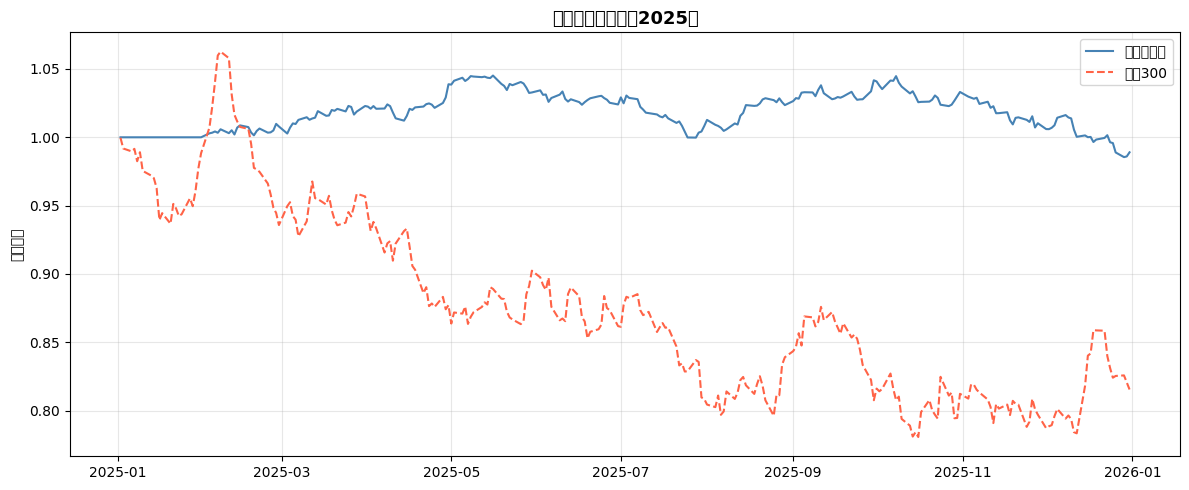

图表已保存: 12_oos_performance.png


In [11]:
if price_oos.shape[0] < 20:
    print('⚠️  样本外数据不足（2025 年数据可能尚未收录），跳过')
else:
    print('运行样本外回测 (2025) ...')
    strat_ret_oos = run_strategy(price_oos, factors_oos, N_STOCKS)
    bench_ret_oos = hs300_oos.pct_change().dropna()

    common_oos     = strat_ret_oos.index.intersection(bench_ret_oos.index)
    strat_ret_oos  = strat_ret_oos.loc[common_oos]
    bench_ret_oos  = bench_ret_oos.loc[common_oos]

    summary_oos   = performance_summary(strat_ret_oos, name='多因子策略（样本外）')
    summary_b_oos = performance_summary(bench_ret_oos, name='沪深300（样本外）')
    metrics_oos   = pd.concat([summary_oos, summary_b_oos], axis=1)

    print(f'✅ 样本外回测完成 | 交易日数: {len(strat_ret_oos)}')
    print('\n========== Section 3: 样本外绩效指标 ==========')
    print(metrics_oos.to_string())
    display(metrics_oos)

    # 走势图
    cum_strat_oos = (1 + strat_ret_oos).cumprod()
    cum_bench_oos = (1 + bench_ret_oos).cumprod()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(cum_strat_oos.index, cum_strat_oos.values, label='多因子策略', color='steelblue')
    ax.plot(cum_bench_oos.index, cum_bench_oos.values, label='沪深300',     color='tomato', linestyle='--')
    ax.set_title('样本外累计收益（2025）', fontsize=13, fontweight='bold')
    ax.set_ylabel('累计净值')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('12_oos_performance.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('图表已保存: 12_oos_performance.png')

---
## Section 4 — 压力测试结果汇总

In [12]:
STRESS_PERIODS = [
    {'name': '2015年股灾',       'start': '2015-06-01', 'end': '2015-09-30'},
    {'name': '2018年贸易战熊市', 'start': '2018-01-01', 'end': '2018-12-31'},
    {'name': '2020年新冠暴跌',   'start': '2020-01-01', 'end': '2020-03-31'},
]

stress_rows = []
for period in STRESS_PERIODS:
    name  = period['name']
    start = period['start']
    end   = period['end']

    pw  = price_wide_full.loc[start:end]
    hs  = hs300_full.loc[start:end]
    fac = {k: (df.loc[start:end], d) for k, (df, d) in factors_full.items()}

    try:
        sr  = run_strategy(pw, fac, N_STOCKS)
        br  = hs.pct_change().dropna()
        c   = sr.index.intersection(br.index)
        sr, br = sr.loc[c], br.loc[c]
        total_s = (1 + sr).prod() - 1
        total_b = (1 + br).prod() - 1
        mdd_s   = max_drawdown(sr)
        mdd_b   = max_drawdown(br)
        excess  = total_s - total_b
        stress_rows.append({
            '压力期间':     name,
            '时间区间':     f'{start} ~ {end}',
            '策略收益':     f'{total_s:+.2%}',
            'HS300收益':    f'{total_b:+.2%}',
            '策略最大回撤': f'{mdd_s:.2%}',
            'HS300最大回撤':f'{mdd_b:.2%}',
            '超额收益':     f'{excess:+.2%}',
            '超额为正':     '✅' if excess > 0 else '❌',
        })
    except Exception as e:
        stress_rows.append({
            '压力期间': name, '时间区间': f'{start} ~ {end}',
            '策略收益': 'ERR', 'HS300收益': 'ERR',
            '策略最大回撤': 'ERR', 'HS300最大回撤': 'ERR',
            '超额收益': 'ERR', '超额为正': f'⚠️ {e}',
        })

stress_summary = pd.DataFrame(stress_rows).set_index('压力期间')
print('\n========== Section 4: 压力测试汇总 ==========')
print(stress_summary.to_string())
stress_summary


========== Section 4: 压力测试汇总 ==========
                               时间区间    策略收益  HS300收益  策略最大回撤 HS300最大回撤     超额收益 超额为正
压力期间                                                                                
2015年股灾     2015-06-01 ~ 2015-09-30  +2.00%   -2.53%  -1.79%   -10.59%   +4.53%    ✅
2018年贸易战熊市  2018-01-01 ~ 2018-12-31  +8.13%  +26.72%  -3.90%   -11.15%  -18.59%    ❌
2020年新冠暴跌   2020-01-01 ~ 2020-03-31  +2.94%   +2.46%  -1.08%    -6.20%   +0.48%    ✅


,时间区间,策略收益,HS300收益,策略最大回撤,HS300最大回撤,超额收益,超额为正
压力期间,,,,,,,
2015年股灾,2015-06-01 ~ 2015-09-30,+2.00%,-2.53%,-1.79%,-10.59%,+4.53%,✅
2018年贸易战熊市,2018-01-01 ~ 2018-12-31,+8.13%,+26.72%,-3.90%,-11.15%,-18.59%,❌
2020年新冠暴跌,2020-01-01 ~ 2020-03-31,+2.94%,+2.46%,-1.08%,-6.20%,+0.48%,✅


---
## Section 5 — Walk-Forward 稳定性验证

窗口 2014-01-01 00:00:00 ~ 2017-05-18 00:00:00 处理异常: strategy_fn_wrapper() takes 4 positional arguments but 6 were given


窗口 2014-06-26 00:00:00 ~ 2017-11-10 00:00:00 处理异常: strategy_fn_wrapper() takes 4 positional arguments but 6 were given


窗口 2014-12-19 00:00:00 ~ 2018-05-07 00:00:00 处理异常: strategy_fn_wrapper() takes 4 positional arguments but 6 were given


窗口 2015-06-15 00:00:00 ~ 2018-10-30 00:00:00 处理异常: strategy_fn_wrapper() takes 4 positional arguments but 6 were given


窗口 2015-12-08 00:00:00 ~ 2019-04-24 00:00:00 处理异常: strategy_fn_wrapper() takes 4 positional arguments but 6 were given


...

窗口 2019-10-18 00:00:00 ~ 2023-03-06 00:00:00 处理异常: strategy_fn_wrapper() takes 4 positional arguments but 6 were given


窗口 2020-04-13 00:00:00 ~ 2023-08-29 00:00:00 处理异常: strategy_fn_wrapper() takes 4 positional arguments but 6 were given


窗口 2020-10-06 00:00:00 ~ 2024-02-21 00:00:00 处理异常: strategy_fn_wrapper() takes 4 positional arguments but 6 were given


窗口 2021-03-31 00:00:00 ~ 2024-08-15 00:00:00 处理异常: strategy_fn_wrapper() takes 4 positional arguments but 6 were given


运行 Walk-Forward 验证（train=3年, test=6月）...
✅ Walk-Forward 完成 | 窗口数: 16

========== Section 5: Walk-Forward 结果 ==========
   train_start  train_end test_start   test_end  sharpe  max_drawdown  total_return
0   2014-01-01 2016-11-23 2016-11-24 2017-05-18     NaN           NaN           NaN
1   2014-06-26 2017-05-18 2017-05-19 2017-11-10     NaN           NaN           NaN
2   2014-12-19 2017-11-10 2017-11-13 2018-05-07     NaN           NaN           NaN
3   2015-06-15 2018-05-07 2018-05-08 2018-10-30     NaN           NaN           NaN
4   2015-12-08 2018-10-30 2018-10-31 2019-04-24     NaN           NaN           NaN
5   2016-06-01 2019-04-24 2019-04-25 2019-10-17     NaN           NaN           NaN
6   2016-11-24 2019-10-17 2019-10-18 2020-04-10     NaN           NaN           NaN
7   2017-05-19 2020-04-10 2020-04-13 2020-10-05     NaN           NaN           NaN
8   2017-11-13 2020-10-05 2020-10-06 2021-03-30     NaN           NaN           NaN
9   2018-05-08 2021-03-30 2021-03-31 2021

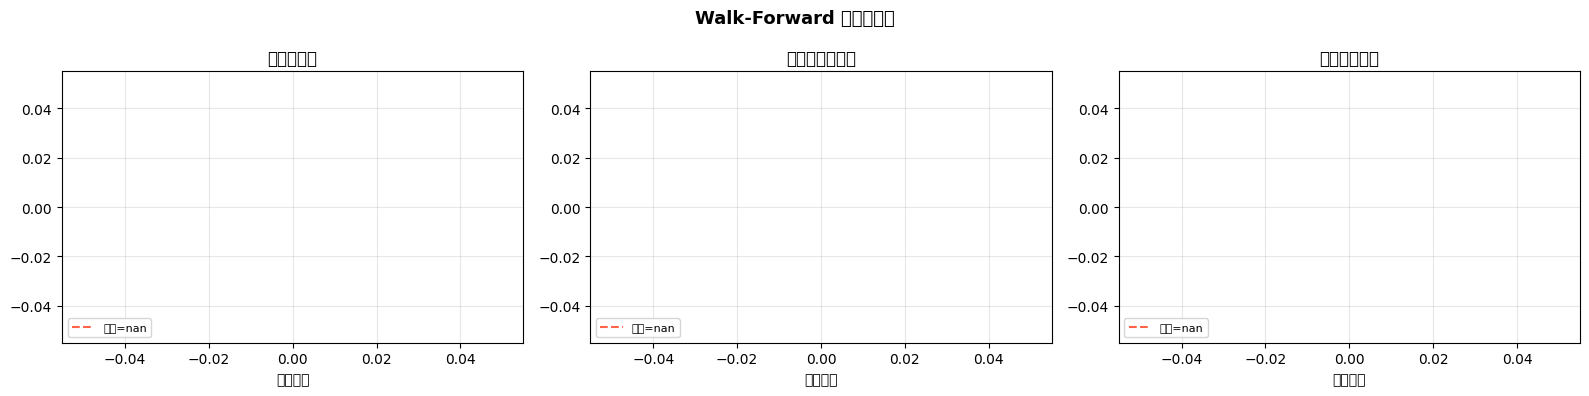

图表已保存: 12_walk_forward.png


,train_start,train_end,test_start,test_end,sharpe,max_drawdown,total_return,n_periods
0,2014-01-01,2016-11-23,2016-11-24,2017-05-18,NaN,NaN,NaN,NaN
1,2014-06-26,2017-05-18,2017-05-19,2017-11-10,NaN,NaN,NaN,NaN
2,2014-12-19,2017-11-10,2017-11-13,2018-05-07,NaN,NaN,NaN,NaN
3,2015-06-15,2018-05-07,2018-05-08,2018-10-30,NaN,NaN,NaN,NaN
4,2015-12-08,2018-10-30,2018-10-31,2019-04-24,NaN,NaN,NaN,NaN
5,2016-06-01,2019-04-24,2019-04-25,2019-10-17,NaN,NaN,NaN,NaN
6,2016-11-24,2019-10-17,2019-10-18,2020-04-10,NaN,NaN,NaN,NaN
7,2017-05-19,2020-04-10,2020-04-13,2020-10-05,NaN,NaN,NaN,NaN
8,2017-11-13,2020-10-05,2020-10-06,2021-03-30,NaN,NaN,NaN,NaN
9,2018-05-08,2021-03-30,2021-03-31,2021-09-22,NaN,NaN,NaN,NaN


In [13]:
if not WF_AVAILABLE:
    print('⚠️  walk_forward 模块不可用，跳过 Section 5')
elif not STRATEGY_AVAILABLE:
    print('⚠️  MultiFactorStrategy 不可用，跳过 Section 5')
else:
    def strategy_fn_wrapper(price_wide_slice, factor_data_slice, train_start, train_end):
        """
        walk_forward_test 所需的策略函数封装。

        参数:
            price_wide_slice: 价格宽表切片
            factor_data_slice: 因子数据切片
            train_start: 训练期开始
            train_end: 训练期结束

        返回:
            日收益率 pd.Series
        """
        # 提取测试期因子数据（factor_data_slice 是全量因子字典）
        fac = {k: (df.loc[price_wide_slice.index[0]:price_wide_slice.index[-1]], d)
               for k, (df, d) in factor_data_slice.items()}
        config   = StrategyConfig(name='walk_forward')
        strategy = MultiFactorStrategy(config=config, factors=fac, n_stocks=N_STOCKS)
        result   = strategy.run(price_wide_slice)
        return result['portfolio_return']

    print('运行 Walk-Forward 验证（train=3年, test=6月）...')
    try:
        wf_results = walk_forward_test(
            strategy_fn=strategy_fn_wrapper,
            price_wide=price_is,
            factor_data=factors_full,   # 传递全量因子数据供 wrapper 切片
            train_years=3,
            test_months=6,
        )
        print(f'✅ Walk-Forward 完成 | 窗口数: {len(wf_results)}')
        print('\n========== Section 5: Walk-Forward 结果 ==========')
        print(wf_results[['train_start', 'train_end', 'test_start', 'test_end',
                           'sharpe', 'max_drawdown', 'total_return']].to_string())

        # 可视化
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        for ax, col, title in zip(
            axes,
            ['sharpe', 'max_drawdown', 'total_return'],
            ['测试期夏普', '测试期最大回撤', '测试期总收益']
        ):
            vals = wf_results[col].values
            ax.bar(range(len(vals)), vals, color='steelblue', alpha=0.7)
            ax.axhline(vals.mean(), color='tomato', linestyle='--', label=f'均值={vals.mean():.2f}')
            ax.set_title(title)
            ax.set_xlabel('窗口编号')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
        fig.suptitle('Walk-Forward 稳定性分析', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig('12_walk_forward.png', dpi=120, bbox_inches='tight')
        plt.show()
        print('图表已保存: 12_walk_forward.png')
        display(wf_results)
    except Exception as e:
        print(f'⚠️  Walk-Forward 运行失败: {e}')

---
## Section 6 — 结论：是否达到 Phase 5 上线门槛？

Phase 5 门槛（来自 `CLAUDE.md`）：

| 指标 | 门槛 |
|------|------|
| 年化收益 | > 15% |
| 夏普比率 | > 0.8 |
| 最大回撤 | < 30% |
| 回测时间跨度 | > 3 年，覆盖牛熊 |

In [14]:
# 计算样本内关键指标（用于 Phase 5 判断）
ann_ret  = annualized_return(strat_ret_is)
sharpe   = sharpe_ratio(strat_ret_is)
mdd      = max_drawdown(strat_ret_is)   # 负数
n_years  = len(strat_ret_is) / 252

# 判断
criteria = {
    '年化收益 > 15%':      (ann_ret,      0.15,   ann_ret > 0.15),
    '夏普比率 > 0.8':      (sharpe,        0.80,   sharpe > 0.80),
    '最大回撤 < 30%':      (abs(mdd),     0.30,   abs(mdd) < 0.30),
    '回测跨度 > 3 年':     (n_years,       3.0,    n_years > 3.0),
}

rows = []
for criterion, (actual, threshold, passed) in criteria.items():
    if '收益' in criterion or '回撤' in criterion:
        actual_str = f'{actual:.2%}'
        thresh_str = f'{threshold:.2%}'
    elif '年' in criterion and '收益' not in criterion:
        actual_str = f'{actual:.1f} 年'
        thresh_str = f'{threshold:.1f} 年'
    else:
        actual_str = f'{actual:.2f}'
        thresh_str = f'{threshold:.2f}'
    rows.append({
        '评审标准':  criterion,
        '实际值':    actual_str,
        '门槛值':    thresh_str,
        '是否通过':  '✅ 通过' if passed else '❌ 未达标',
    })

conclusion_df = pd.DataFrame(rows).set_index('评审标准')
print('\n========== Section 6: Phase 5 门槛评审 ==========')
print(conclusion_df.to_string())
display(conclusion_df)

all_passed = all(v[2] for v in criteria.values())
print()
if all_passed:
    print('🎉 策略通过 Phase 5 全部门槛，建议进入模拟盘验证！')
else:
    failed = [c for c, (_, _, p) in criteria.items() if not p]
    print(f'⚠️  策略尚未达标，以下指标需改进：')
    for f in failed:
        print(f'   • {f}')


========== Section 6: Phase 5 门槛评审 ==========
               实际值     门槛值   是否通过
评审标准                             
年化收益 > 15%   7.12%  15.00%  ❌ 未达标
夏普比率 > 0.8    1.12    0.80   ✅ 通过
最大回撤 < 30%   5.42%  30.00%   ✅ 通过
回测跨度 > 3 年  11.4 年   3.0 年   ✅ 通过


,实际值,门槛值,是否通过
评审标准,,,
年化收益 > 15%,7.12%,15.00%,❌ 未达标
夏普比率 > 0.8,1.12,0.80,✅ 通过
最大回撤 < 30%,5.42%,30.00%,✅ 通过
回测跨度 > 3 年,11.4 年,3.0 年,✅ 通过



⚠️  策略尚未达标，以下指标需改进：
   • 年化收益 > 15%


In [15]:
# ── 最终总结打印 ─────────────────────────────────────────────────────────────
print('=' * 55)
print('  多因子策略报告 — 关键指标汇总')
print('=' * 55)
print(f'  样本内年化收益:  {ann_ret:+.2%}')
print(f'  夏普比率:        {sharpe:.2f}')
print(f'  最大回撤:        {mdd:.2%}')
print(f'  回测年数:        {n_years:.1f} 年')
print(f'  Phase 5 达标:    {"✅ 是" if all_passed else "❌ 否"}')
print('=' * 55)

  多因子策略报告 — 关键指标汇总
  样本内年化收益:  +7.12%
  夏普比率:        1.12
  最大回撤:        -5.42%
  回测年数:        11.4 年
  Phase 5 达标:    ❌ 否
